In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import math
from scipy.optimize import curve_fit
import powerlaw
from tqdm import tqdm

# Seaborn has way better visualizations and its built on top of matplotlib
import seaborn as sns
from scipy.optimize import curve_fit

In [3]:
# Run before running the graph code cause it preloads the nodes
nodes = pd.read_csv('./GEPHI/project_nodes.csv')

# Same idea as the professors code in Week 3
all_degrees = nodes['Degree'].values
kmin = max(1, all_degrees.min())
kmax = all_degrees.max()


In [37]:
# Function to calculate paths with progress
# Must more optimized using nx.single_source_shortest_path_length instead of calculating each pair separately
# Plus I can see progress
def calculate_paths_with_progress(graph):
    all_nodes = list(graph.nodes())
    number_of_nodes = len(all_nodes)

    total_paths = 0
    length_of_paths = 0
    max_length_path = 0

    with tqdm(total=number_of_nodes, desc="Calculating node paths") as progress_bar:
        for node_source in all_nodes:

            # https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.unweighted.single_source_shortest_path.html#networkx.algorithms.shortest_paths.unweighted.single_source_shortest_path
            paths = nx.single_source_shortest_path_length(G, node_source)

            for node_target, length in paths.items():

                # To avoid self loops cause that isn't needed (would just be 0)
                if node_target != node_source:
                    length_of_paths += length
                    max_length_path = max(max_length_path, length)
                    total_paths += 1

            progress_bar.update(1)

    average_length = length_of_paths / total_paths

    return average_length, max_length_path


In [ ]:
# -------------------------------------------------------------
# DEGREE DISTRIBUTION
#--------------------------------------------------------------

Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating best minimal value for power law fit
Degree exponent (γ): 2.262738468326398
This network is in Scale-Free Regime


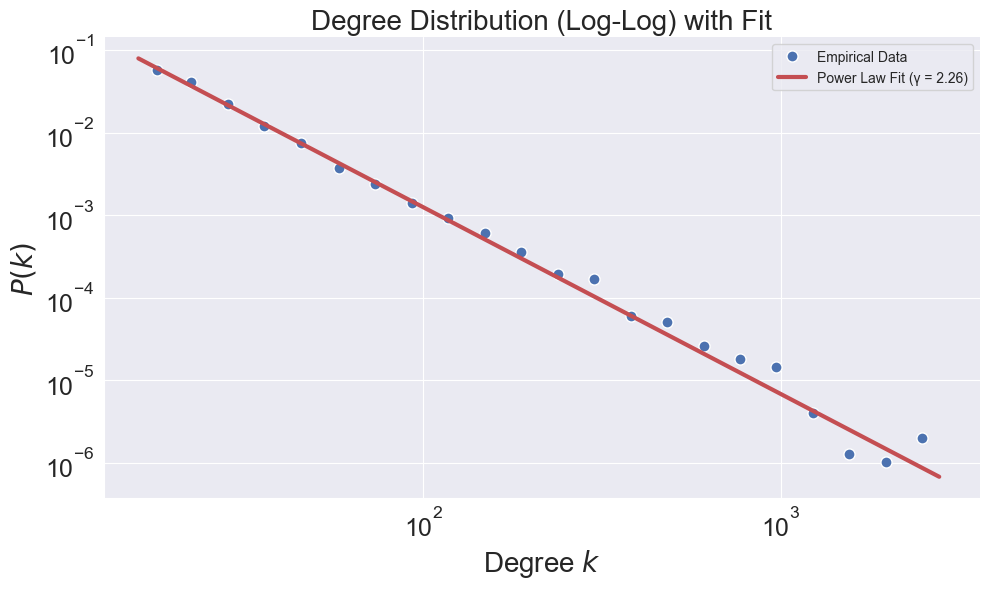

In [4]:
# Will use the power law library since that is WAY more reliable
# https://github.com/schae234/powerlaw
fitted_vals = powerlaw.Fit(all_degrees)
gamma = fitted_vals.alpha
xmin = fitted_vals.xmin

# Now I have the degree exponent (gamma)
print(f"Degree exponent (γ): {gamma}")
# From section 4.7, going to check what regime this falls into, based off the gamma I just got
# Anomalous regime (γ <= 2)
if gamma <= 2:
    print("This network is in Anomalous Regime")
# Scale-Free regime (2 < γ < 3)
elif 2 < gamma < 3:
    print("This network is in Scale-Free Regime")

# Random network regime (3 > γ)
elif 3 > gamma:
    print("This network is in Random Network Regime")

plt.figure(figsize=(10, 6))
fig = fitted_vals.plot_pdf(
    color=sns.color_palette("deep")[0],
    marker='o',
    markersize=8,
    markeredgecolor='white',
    markeredgewidth=1,
    linestyle='none',
    label='Empirical Data'
)

fitted_vals.power_law.plot_pdf(
    color=sns.color_palette("deep")[3],
    linestyle='-',
    linewidth=3,
    ax=fig,
    label=f'Power Law Fit (γ = {gamma:.2f})'
)

plt.xlabel(r"Degree $k$", fontsize=20)
plt.ylabel(r"$P(k)$", fontsize=20)
plt.title(r"Degree Distribution (Log-Log) with Fit", fontsize=20)
plt.legend()

# Setting the axis limits. Same as the professors code
ax = plt.gca()
ax.set_xlim(xmin * 0.8, max(all_degrees) * 1.3)

sns.despine()

plt.tick_params(axis='both', which='major', labelsize=18)

plt.tight_layout()
plt.savefig("./Images/degree_dist_powerlaw.png", dpi=300, bbox_inches='tight')
plt.show()


plt.show()


In [ ]:
""# -------------------------------------------------------------
# LOADING GRAPH FIRST BEFORE THE OTHER CALCULATIONS
#--------------------------------------------------------------

In [17]:
G = nx.read_graphml("./NetworkFiles/network_graph_symptom.graphml")

In [ ]:
# -------------------------------------------------------------
# Number of connected components
#--------------------------------------------------------------

In [6]:
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.number_connected_components.html
num_con_comps = nx.number_connected_components(G)
print(f"Number of connected components: {num_con_comps}")

Number of connected components: 347


In [ ]:
# -------------------------------------------------------------
# Clustering coefficient
#--------------------------------------------------------------

In [9]:
# This is in the textbook, Chapter 2 (Section 2.10)
# This is the degree to which the neighbours of a given node link to each other.
average_clustering = nx.average_clustering(G)
print(f"Average clustering coefficient: {average_clustering}")

Average clustering coefficient: 0.8471065580443585


In [ ]:
## -------------------------------------------------------------
# Path length
#--------------------------------------------------------------

In [38]:
# This is from chapter 3 notes (section 3.8)
# So if the graph has multiple components we calculate for the largest component.
# Tested before and it is actually not connected
try:
    average_path_length = nx.average_shortest_path_length(G)
    diameter = nx.diameter(G)
    print(f"Average path length: {average_path_length}")
    # The diameter is the maximum shortest path
    print(f"Diameter of network: {diameter}")
except nx.NetworkXError:
    print("Graph is not connected...So calculate the largest connected component")
    connected_components = nx.connected_components(G)
    largest_connected_comp = max(connected_components, key=len)

    # https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html
    largest_subgraph = nx.subgraph(G, largest_connected_comp)

    largest_average_path_length, largest_diameter = calculate_paths_with_progress(largest_subgraph)

    print(f"Average path length of largest component: {largest_average_path_length}")
    # The diameter is the maximum shortest path
    print(f"Diameter of network of largest component: {largest_diameter}")

    num_nodes_subgraph = len(largest_subgraph.nodes())
    num_nodes_graph = len(G.nodes())

    percentage_of_nodes = (num_nodes_subgraph / num_nodes_graph) * 100
    print(f"Percentage of nodes in largest component: {percentage_of_nodes}")



Graph is not connected...So calculate the largest connected component


Calculating node paths: 100%|██████████| 15011/15011 [18:11<00:00, 13.76it/s]

Average path length of largest component: 2.9978642178058985
Diameter of network of largest component: 8
Percentage of nodes in largest component: 93.91853844710005
